<a href="https://colab.research.google.com/github/ftama0/colab-palm-detector/blob/v1/palm_detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [2]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.7/77.7 kB 8.9 MB/s eta 0:00:00


In [3]:
from google.colab import files

uploaded = files.upload()

Saving Oil Palm Fruit Ripeness - Only Palm Fruit detection.yolov11.zip to Oil Palm Fruit Ripeness - Only Palm Fruit detection.yolov11.zip


In [4]:
import zipfile
import os

zip_file = next(iter(uploaded))

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Extract selesai:", zip_file)

Extract selesai: Oil Palm Fruit Ripeness - Only Palm Fruit detection.yolov11.zip


In [5]:
!find /content/dataset -maxdepth 3 -type f | head -40

/content/dataset/valid/images/frameterlalumasak9--34-_png_jpg.rf.7MXORxqulXHVGTCypK0h.jpg
/content/dataset/valid/images/framesawit23--21-_png_jpg.rf.Ny4EO90h3ggfdEHJuZdq.jpg
/content/dataset/valid/images/framesawit12--20-_png_jpg.rf.oMuzFu07YV0RkqGlkdeo.jpg
/content/dataset/valid/images/framementah9--13-_png_jpg.rf.9AYvlVxkJnQcsd1ogYR6.jpg
/content/dataset/valid/images/framementah21--28-_png_jpg.rf.b1GRoOlZyBAZ7IhUw4yE.jpg
/content/dataset/valid/images/frameterlalumasak10--29-_png_jpg.rf.tz21BJ5e2GjZV0z80YtO.jpg
/content/dataset/valid/images/frameterlalumasak9--36-_png_jpg.rf.oR7FlvHNlChqa1wdEJDU.jpg
/content/dataset/valid/images/frameterlalumasak13--19-_png_jpg.rf.26sjEFbndFarKPondlxI.jpg
/content/dataset/valid/images/framesawit42--18-_png_jpg.rf.WNenqflasInEDa1Jn9eO.jpg
/content/dataset/valid/images/frame10--7-_png_jpg.rf.GpK4NDm7JKxLFE4uW2I8.jpg
/content/dataset/valid/images/framementah9--2-_png_jpg.rf.tEN7v5TXthpaT7aqo0dx.jpg
/content/dataset/valid/images/framekurangmasak9--21-_png

In [6]:
!cat /content/dataset/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['palm_fruit']

roboflow:
  workspace: ferry-pratama
  project: oil-palm-fruit-ripeness-only-palm-fruit-detection
  version: dataset
  license: CC BY 4.0
  url: https://universe.roboflow.com/ferry-pratama/oil-palm-fruit-ripeness-only-palm-fruit-detection/dataset/dataset

In [7]:
import os

for folder in ["train", "valid", "test"]:
    image_dir = f"/content/dataset/{folder}/images"
    label_dir = f"/content/dataset/{folder}/labels"

    images = len(os.listdir(image_dir)) if os.path.exists(image_dir) else 0
    labels = len(os.listdir(label_dir)) if os.path.exists(label_dir) else 0

    print(f"{folder}: images={images}, labels={labels}")

train: images=2908, labels=2908
valid: images=835, labels=835
test: images=426, labels=426


In [8]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [9]:
results = model.train(
    data="/content/dataset/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None, optimize=Fa

In [10]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/train/weights/best.pt")

In [11]:
test_results = best_model.val(
    data="/content/dataset/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1379.4±388.0 MB/s, size: 41.8 KB)
val: Scanning /content/dataset/test/labels... 426 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 426/426 1.9Kit/s 0.2s
val: New cache created: /content/dataset/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 176, len(boxes) = 1586. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 3.6it/s 7.5s
                   all        426       1586      0.986      0.931      0.954      0.851
Speed: 2.0ms preprocess, 4.7ms inference, 0.0ms loss, 1.9ms postprocess per i

In [13]:
!find /content -name "*.pt" -type f

/content/yolo11n.pt
/content/weights/yolo26n.pt
/content/runs/detect/train/weights/last.pt
/content/runs/detect/train/weights/best.pt


In [43]:
from google.colab import files

uploaded = files.upload()

Saving sawit1.jpeg to sawit1.jpeg



image 1/1 /content/WhatsApp Image 2026-08-18 at 2.13.47 PM.jpeg: 960x1280 20 palm_fruits, 40.5ms
Speed: 6.0ms preprocess, 40.5ms inference, 1.5ms postprocess per image at shape (1, 3, 960, 1280)
Box 1: conf=0.930, xyxy=[792.3519897460938, 733.8475341796875, 1134.236083984375, 1111.8067626953125]
Box 2: conf=0.927, xyxy=[302.2469787597656, 638.8043823242188, 653.2886962890625, 966.7235717773438]
Box 3: conf=0.911, xyxy=[499.5556640625, 814.88623046875, 804.5111083984375, 1159.88818359375]
Box 4: conf=0.900, xyxy=[120.68464660644531, 370.0154113769531, 457.49700927734375, 719.6393432617188]
Box 5: conf=0.891, xyxy=[921.3873901367188, 363.71978759765625, 1139.2723388671875, 514.0545654296875]
Box 6: conf=0.890, xyxy=[570.0377807617188, 570.1383056640625, 925.0261840820312, 811.75390625]
Box 7: conf=0.863, xyxy=[456.962646484375, 303.9814453125, 739.6134033203125, 641.2935791015625]
Box 8: conf=0.830, xyxy=[889.9667358398438, 513.9744873046875, 1088.98388671875, 687.26220703125]
Box 9: co

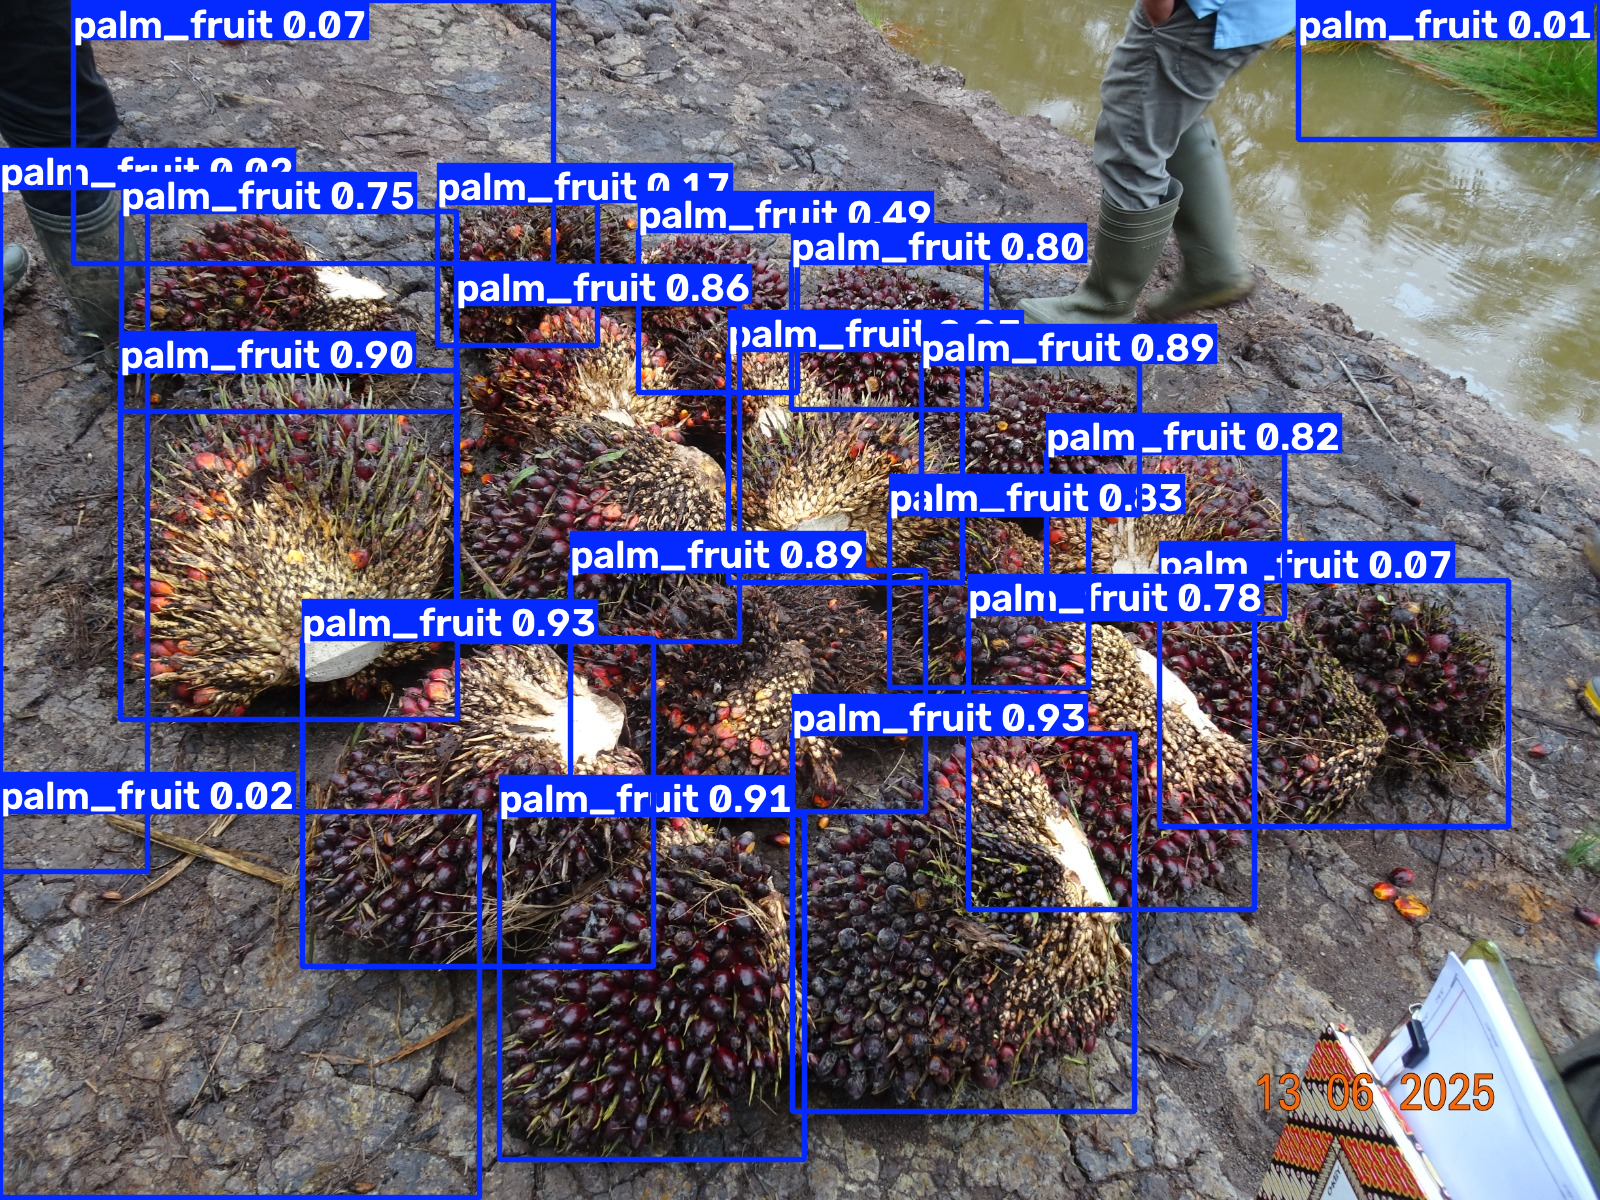

In [45]:
results = best_model.predict(
    source=image_path,
    imgsz=1280,
    conf=0.01,
    iou=0.45,
    augment=True,
    device=0
)

result = results[0]

for i, box in enumerate(result.boxes):
    print(
        f"Box {i+1}: "
        f"conf={float(box.conf[0]):.3f}, "
        f"xyxy={box.xyxy[0].tolist()}"
    )

result.show()


image 1/1 /content/sawit1.jpeg: 832x1280 12 palm_fruits, 163.1ms
Speed: 4.5ms preprocess, 163.1ms inference, 1.6ms postprocess per image at shape (1, 3, 832, 1280)
Results saved to /content/runs/detect/predict


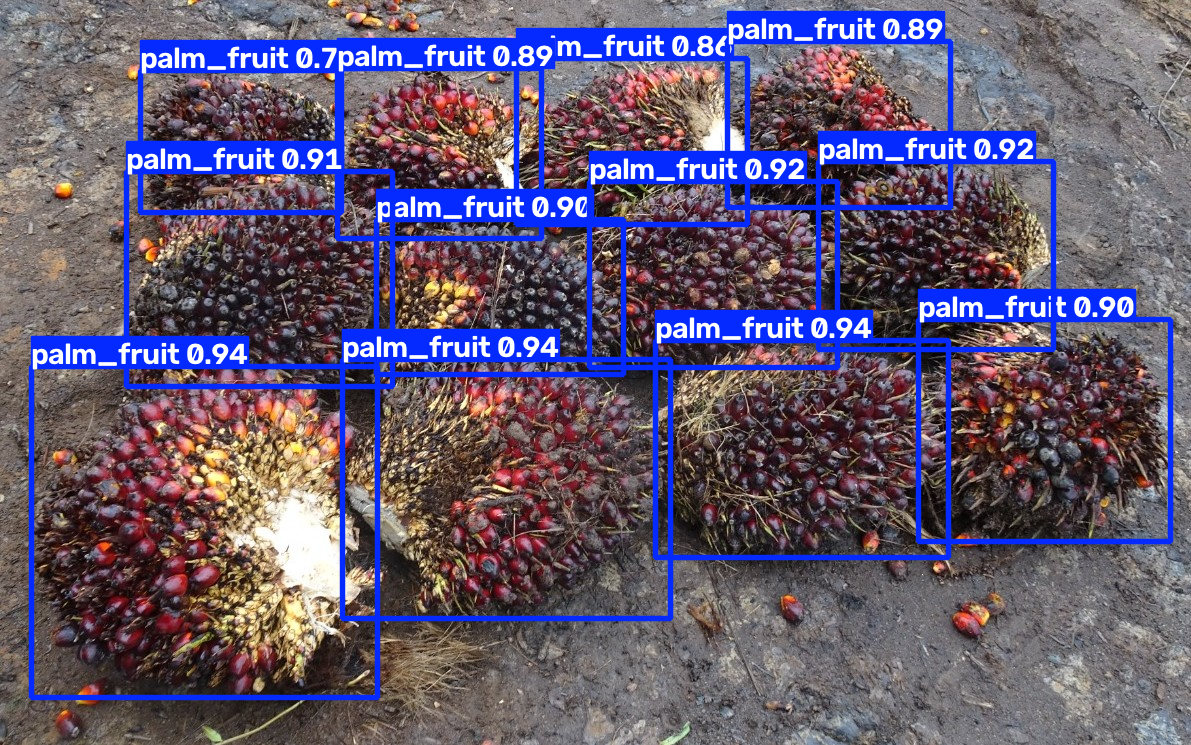

Jumlah terdeteksi: 12


In [46]:
image_path = next(iter(uploaded))

results = best_model.predict(
    source=image_path,
    imgsz=1280,
    conf=0.05,
    device=0,
    iou=0.45,
    augment=True,
    save=True
)

results[0].show()
result = results[0]

print("Jumlah terdeteksi:", len(result.boxes))

In [47]:
!ls -lh /content/runs/detect/train/weights/

total 11M
-rw-r--r-- 1 root root 5.3M Sep 16 03:23 best.pt
-rw-r--r-- 1 root root 5.3M Sep 16 03:23 last.pt


In [48]:
from google.colab import files

files.download('/content/runs/detect/train/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
!zip -j /content/yolo_model.zip \
    /content/runs/detect/train/weights/best.pt \
    /content/runs/detect/train/weights/last.pt

  adding: best.pt (deflated 10%)
  adding: last.pt (deflated 10%)


In [50]:
from ultralytics import YOLO

# Load model hasil training
model = YOLO("/content/runs/detect/train/weights/best.pt")

# Export ke ONNX
model.export(
    format="onnx",
    imgsz=640,
    simplify=True
)

Ultralytics 8.4.153 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (5.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxruntime', 'onnxslim>=0.1.82'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 12 packages in 284ms
Prepared 4 packages in 1.01s
Installed 4 packages in 272ms
 + colorama==0.4.6
 + onnx==1.22.0
 + onnxruntime==1.30.0
 + onnxslim==0.1.96

requirements: AutoUpdate success ✅ 2.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming wi

'/content/runs/detect/train/weights/best.onnx'

In [52]:
from google.colab import files

files.download("/content/runs/detect/train/weights/best.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>